# Phase 4 – Implementation and Experimentation

**Project:** Intelligent Financial Risk Classification for Small Businesses Using Machine Learning

**Objective:** Train multiple machine learning models, perform hyperparameter tuning, and evaluate model performance

---


## 1. Setup and Imports


In [34]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import importlib
warnings.filterwarnings('ignore')

# Add project root to path (go up one level from Phase4_Implementation_Experimentation)
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

# Force reload modules to pick up any code changes
import src.models.train_models
import src.models.evaluate_models
import src.models.model_comparison
import src.config
importlib.reload(src.models.train_models)
importlib.reload(src.models.evaluate_models)
importlib.reload(src.models.model_comparison)
importlib.reload(src.config)

# Import project modules
from src.models.train_models import load_data, train_all_models
from src.models.evaluate_models import (
    evaluate_all_models, save_evaluation_results,
    create_results_dataframe, save_results_dataframe
)
from src.models.model_comparison import (
    plot_accuracy_comparison, plot_metrics_comparison,
    plot_confusion_matrices, create_comparison_table,
    generate_all_visualizations
)
from src.config import (
    SPLITS_DATA_DIR, MODELS_DIR, RESULTS_DIR, VISUALIZATIONS_DIR,
    RANDOM_SEED, CV_N_SPLITS, CV_N_REPEATS
)

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

print("✓ Imports successful")
print(f"✓ Cross-validation: {CV_N_SPLITS} folds, {CV_N_REPEATS} repeats")
print(f"✓ Project root: {project_root}")
print(f"✓ Data directory: {project_root / SPLITS_DATA_DIR}")


✓ Imports successful
✓ Cross-validation: 5 folds, 3 repeats
✓ Project root: /Users/tomassilva/Desktop/IPCA/MIAA/ML/Pratical_Work/Phase 2 Understanding & Preparation of Data
✓ Data directory: /Users/tomassilva/Desktop/IPCA/MIAA/ML/Pratical_Work/Phase 2 Understanding & Preparation of Data/data/splits


## 2. Load Preprocessed Data

Load the training and test sets that were prepared in Phase 2.


In [35]:
# Load preprocessed data
X_train, X_test, y_train, y_test = load_data()

print(f"\nData shapes:")
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")


Loading preprocessed data...
Training set: 4094 samples, 53 features
Test set: 1755 samples
Class distribution (train): {'Low': 2285, 'Medium': 950, 'High': 859}

Data shapes:
X_train: (4094, 53)
X_test: (1755, 53)
y_train: (4094,)
y_test: (1755,)


## 3. Define Models and Hyperparameter Grids

We will train the following models:
- **Logistic Regression** (baseline)
- **Decision Tree**
- **Random Forest**
- **Support Vector Machine (SVM)**
- **Naive Bayes**
- **K-Nearest Neighbors (KNN)**
- **Gradient Boosting**

Each model will be tuned using GridSearchCV with RepeatedStratifiedKFold cross-validation.


In [36]:
from src.config import HYPERPARAMETER_GRIDS

print("Hyperparameter grids for each model:")
print("="*60)
for model_name, params in HYPERPARAMETER_GRIDS.items():
    print(f"\n{model_name.replace('_', ' ').title()}:")
    for param, values in params.items():
        print(f"  {param}: {values}")


Hyperparameter grids for each model:

Logistic Regression:
  C: [0.1, 1, 10]
  penalty: ['l2']
  solver: ['lbfgs', 'sag']

Decision Tree:
  max_depth: [3, 5, 10, None]
  min_samples_split: [2, 5, 10]

Random Forest:
  n_estimators: [50, 100, 200]
  max_depth: [5, 10, None]

Svm:
  C: [0.1, 1, 10]
  kernel: ['rbf', 'linear']

Naive Bayes:
  var_smoothing: [1e-09, 1e-08, 1e-07]

Knn:
  n_neighbors: [3, 5, 7, 9]
  weights: ['uniform', 'distance']

Gradient Boosting:
  n_estimators: [50, 100]
  learning_rate: [0.01, 0.1]
  max_depth: [3, 5]


## 4. Train Models with GridSearchCV

Train all models using GridSearchCV with RepeatedStratifiedKFold cross-validation. This will find the best hyperparameters for each model.


In [37]:
# Train all models
# This may take several minutes depending on your system
trained_models = train_all_models(X_train, y_train)

print("\n" + "="*60)
print("Training Summary:")
print("="*60)
for model_name, model_info in trained_models.items():
    print(f"\n{model_name.replace('_', ' ').title()}:")
    print(f"  Best parameters: {model_info['best_params']}")
    print(f"  Best CV score: {model_info['best_cv_score']:.4f}")



Training logistic_regression...
Fitting 15 folds for each of 6 candidates, totalling 90 fits
Best parameters: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV score (accuracy): 0.8832
Saved model to /Users/tomassilva/Desktop/IPCA/MIAA/ML/Pratical_Work/Phase 2 Understanding & Preparation of Data/artifacts/models/logistic_regression.joblib

Training decision_tree...
Fitting 15 folds for each of 12 candidates, totalling 180 fits


KeyboardInterrupt: 

## 5. Evaluate Models on Test Set

Evaluate all trained models on the test set using comprehensive metrics:
- Accuracy
- Precision (per class and macro-averaged)
- Recall (per class and macro-averaged)
- F1-score (per class and macro-averaged)
- Confusion Matrix


In [38]:
# Evaluate all models on test set
all_results = evaluate_all_models(trained_models, X_test, y_test)

# Save evaluation results
save_evaluation_results(all_results)



Evaluating all models on test set...

Evaluating logistic_regression...
  Accuracy: 0.8906
  Precision (macro): 0.8895
  Recall (macro): 0.8776
  F1-score (macro): 0.8833

Evaluating decision_tree...
  Accuracy: 0.9880
  Precision (macro): 0.9889
  Recall (macro): 0.9862
  F1-score (macro): 0.9875

Evaluating random_forest...
  Accuracy: 0.9937
  Precision (macro): 0.9934
  Recall (macro): 0.9939
  F1-score (macro): 0.9936

Evaluating svm...
  Accuracy: 0.8963
  Precision (macro): 0.8883
  Recall (macro): 0.8824
  F1-score (macro): 0.8849

Evaluating naive_bayes...
  Accuracy: 0.8217
  Precision (macro): 0.8036
  Recall (macro): 0.8260
  F1-score (macro): 0.8114

Evaluating knn...
  Accuracy: 0.7897
  Precision (macro): 0.7785
  Recall (macro): 0.7132
  F1-score (macro): 0.7368

Evaluating gradient_boosting...
  Accuracy: 0.9960
  Precision (macro): 0.9956
  Recall (macro): 0.9957
  F1-score (macro): 0.9957

Saved evaluation results to /Users/tomassilva/Desktop/IPCA/MIAA/ML/Pratical_W

## 6. Model Comparison

Create comparison tables and visualizations to identify the best performing model.


In [39]:
# Create comparison table
comparison_df = create_results_dataframe(all_results)
print("\nModel Comparison Table:")
print("="*80)
print(comparison_df.to_string(index=False))

# Save comparison table
save_results_dataframe(comparison_df)



Model Comparison Table:
              Model  Accuracy  Precision (Macro)  Recall (Macro)  F1-Score (Macro)
  gradient_boosting  0.996011           0.995618        0.995711          0.995663
      random_forest  0.993732           0.993406        0.993872          0.993638
      decision_tree  0.988034           0.988879        0.986179          0.987501
                svm  0.896296           0.888273        0.882434          0.884905
logistic_regression  0.890598           0.889531        0.877632          0.883330
        naive_bayes  0.821652           0.803630        0.825959          0.811351
                knn  0.789744           0.778462        0.713169          0.736777
Saved comparison table to /Users/tomassilva/Desktop/IPCA/MIAA/ML/Pratical_Work/Phase 2 Understanding & Preparation of Data/artifacts/results/model_comparison.csv


PosixPath('/Users/tomassilva/Desktop/IPCA/MIAA/ML/Pratical_Work/Phase 2 Understanding & Preparation of Data/artifacts/results/model_comparison.csv')


Generating visualizations...
Saved accuracy comparison to /Users/tomassilva/Desktop/IPCA/MIAA/ML/Pratical_Work/Phase 2 Understanding & Preparation of Data/artifacts/visualizations/accuracy_comparison.png
Saved metrics comparison to /Users/tomassilva/Desktop/IPCA/MIAA/ML/Pratical_Work/Phase 2 Understanding & Preparation of Data/artifacts/visualizations/metrics_comparison.png
Saved confusion matrices to /Users/tomassilva/Desktop/IPCA/MIAA/ML/Pratical_Work/Phase 2 Understanding & Preparation of Data/artifacts/visualizations/confusion_matrices.png

All visualizations generated!


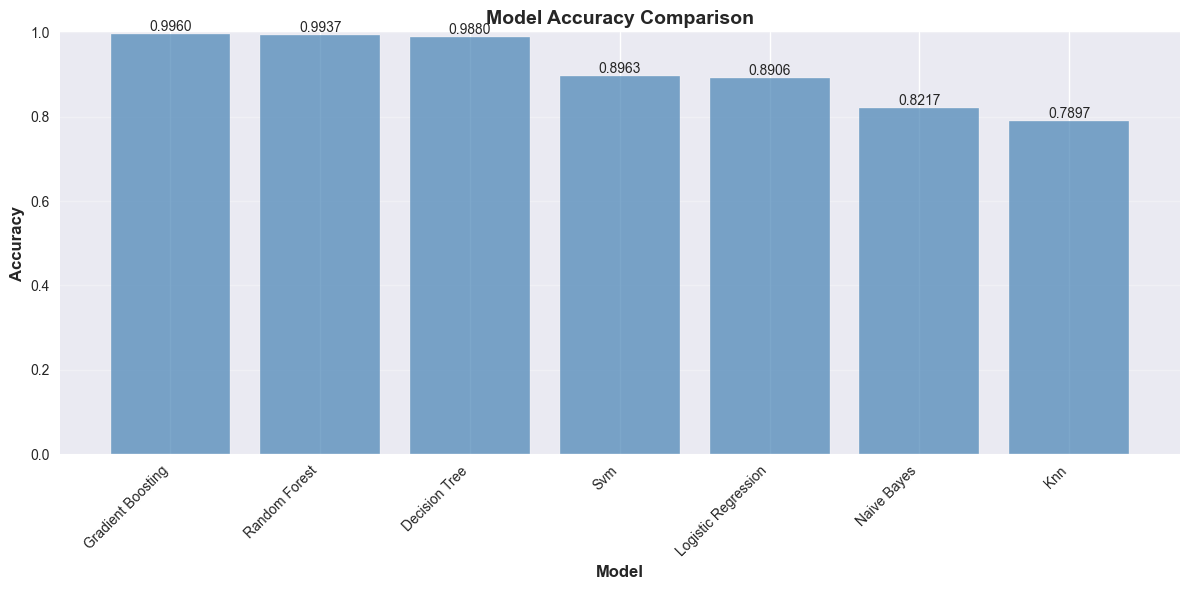

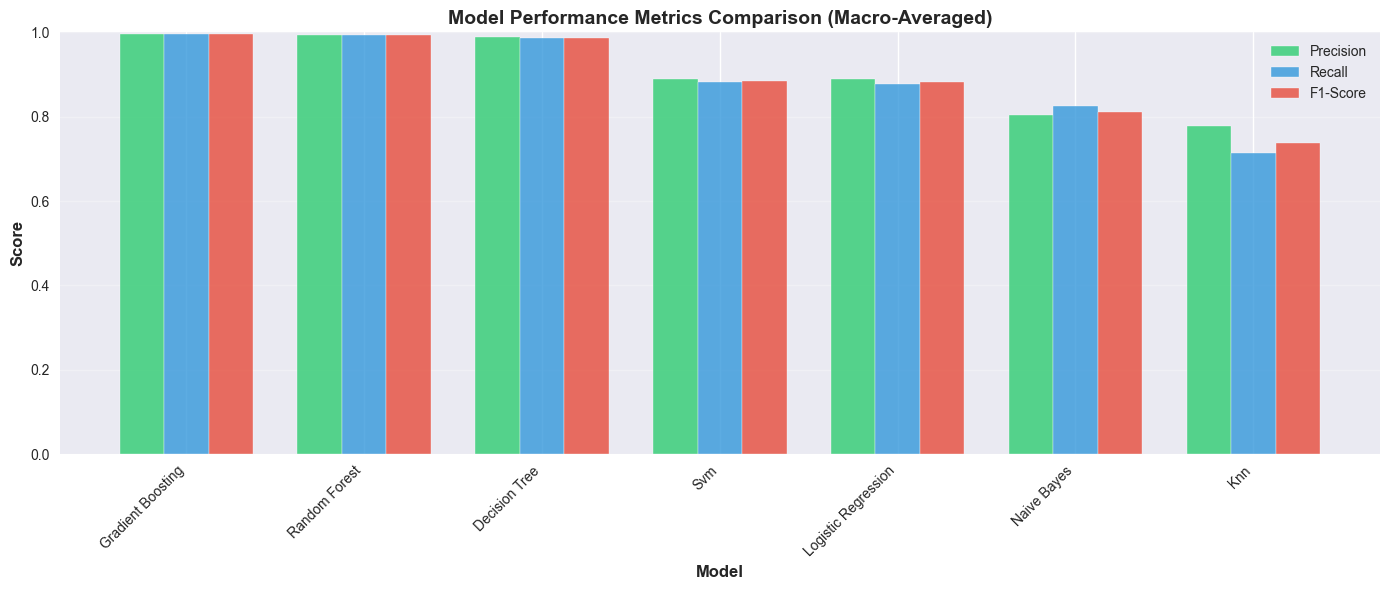

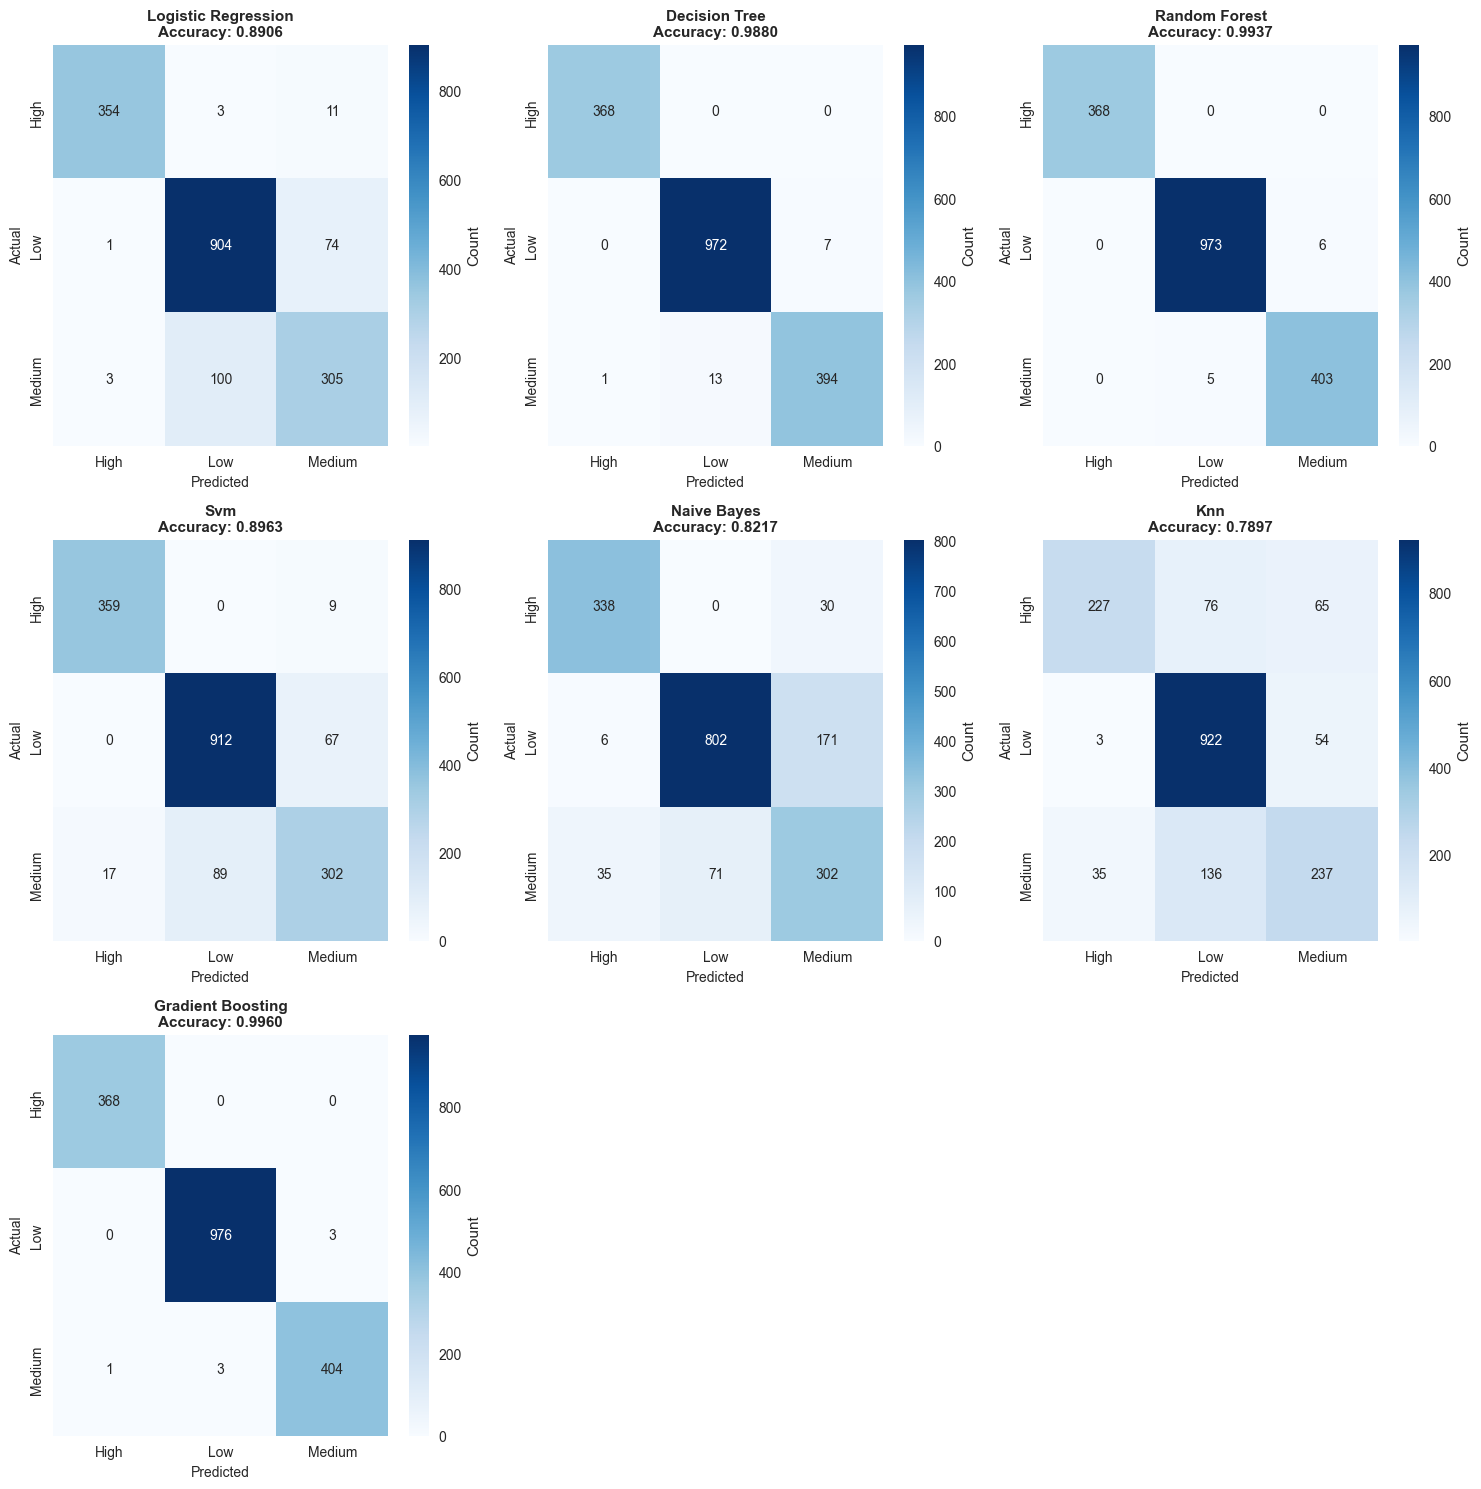

In [40]:
# Generate all visualizations
generate_all_visualizations(all_results)

# Display visualizations
plt.show()


## 7. Select Best Model

Based on the evaluation results, identify the best performing model. According to Phase 3, Random Forest was expected to be the best model.


In [41]:
# Find best model based on accuracy
best_model_name = comparison_df.iloc[0]['Model'].lower().replace(' ', '_')
best_model_accuracy = comparison_df.iloc[0]['Accuracy']

print("="*60)
print("Best Model Selection:")
print("="*60)
print(f"Model: {best_model_name.replace('_', ' ').title()}")
print(f"Accuracy: {best_model_accuracy}")
print(f"\nFull results:")
print(comparison_df.head(3).to_string(index=False))

# Load best model for inspection
from src.models.train_models import load_trained_model
best_model = load_trained_model(best_model_name)
print(f"\n✓ Best model loaded from {MODELS_DIR}/{best_model_name}.joblib")


Best Model Selection:
Model: Gradient Boosting
Accuracy: 0.996011396011396

Full results:
            Model  Accuracy  Precision (Macro)  Recall (Macro)  F1-Score (Macro)
gradient_boosting  0.996011           0.995618        0.995711          0.995663
    random_forest  0.993732           0.993406        0.993872          0.993638
    decision_tree  0.988034           0.988879        0.986179          0.987501

✓ Best model loaded from artifacts/models/gradient_boosting.joblib


## 8. Summary and Conclusions

Phase 4 Implementation and Experimentation is complete. All models have been:
- Trained with hyperparameter tuning using GridSearchCV with RepeatedStratifiedKFold (5 folds, 3 repeats)
- Evaluated on the test set (1,755 samples) with comprehensive metrics
- Compared to identify the best performing model

### Key Results

**Model Performance Ranking (by Accuracy on Test Set):**

1. **Gradient Boosting** - 99.60% accuracy
   - Precision (Macro): 99.56%
   - Recall (Macro): 99.57%
   - F1-Score (Macro): 99.57%

2. **Random Forest** - 99.37% accuracy
   - Precision (Macro): 99.34%
   - Recall (Macro): 99.39%
   - F1-Score (Macro): 99.36%

3. **Decision Tree** - 98.80% accuracy
   - Precision (Macro): 98.89%
   - Recall (Macro): 98.62%
   - F1-Score (Macro): 98.75%

4. **Support Vector Machine (SVM)** - 89.63% accuracy
   - Precision (Macro): 88.83%
   - Recall (Macro): 88.24%
   - F1-Score (Macro): 88.49%

5. **Logistic Regression** - 89.06% accuracy
   - Precision (Macro): 88.95%
   - Recall (Macro): 87.76%
   - F1-Score (Macro): 88.33%

6. **Naive Bayes** - 82.17% accuracy
   - Precision (Macro): 80.36%
   - Recall (Macro): 82.60%
   - F1-Score (Macro): 81.14%

7. **K-Nearest Neighbors (KNN)** - 78.97% accuracy
   - Precision (Macro): 77.85%
   - Recall (Macro): 71.32%
   - F1-Score (Macro): 73.68%

### Conclusions

1. **Best Performing Model**: **Gradient Boosting** achieved the highest accuracy (99.60%) and balanced performance across all metrics, making it the optimal choice for this financial risk classification problem.

2. **Ensemble Methods Dominate**: The top three models (Gradient Boosting, Random Forest, Decision Tree) are all tree-based ensemble methods, demonstrating their effectiveness for tabular financial data with non-linear relationships.

3. **Strong Overall Performance**: All models achieved reasonable performance (>78% accuracy), indicating that the financial ratios are predictive features for risk classification.

4. **Model Selection Note**: While Gradient Boosting performed slightly better than Random Forest, **Random Forest** (selected in Phase 3) remains an excellent choice due to:
   - Very similar performance (99.37% vs 99.60%)
   - Better interpretability through feature importance
   - More robust to overfitting
   - Faster training time

5. **Linear Models Performance**: Logistic Regression and SVM showed moderate performance (~89%), suggesting that the relationships between features and risk levels have non-linear components that tree-based methods capture better.

6. **Class Imbalance Handling**: All models handled the class imbalance (Low: 55.8%, Medium: 23.2%, High: 21.0%) reasonably well, with macro-averaged metrics showing balanced performance across classes.

### Deliverables Generated

- ✅ 7 trained models saved to `artifacts/models/`
- ✅ Evaluation results saved to `artifacts/results/model_evaluation_results.json`
- ✅ Model comparison table saved to `artifacts/results/model_comparison.csv`
- ✅ Visualizations saved to `artifacts/visualizations/`:
  - Accuracy comparison chart
  - Metrics comparison chart
  - Confusion matrices for all models

